# README

Notebook ini berisi alur kerja lengkap untuk peramalan penjualan, mencakup langkah-langkah berikut:

*   **Pemuatan dan Pembersihan Data**: Memuat data transaksi penjualan dari file CSV, membersihkan, dan mempersiapkannya untuk analisis.
*   **Rekayasa Fitur (Feature Engineering)**: Membuat fitur-fitur baru berbasis waktu (seperti tahun, bulan, hari dalam seminggu), statistik bergulir (rata-rata, standar deviasi, min, max), perubahan persentase, dan komponen Fourier untuk menangkap pola musiman.
*   **Analisis Korelasi**: Menganalisis korelasi antar fitur dan terhadap target penjualan untuk memilih fitur yang paling relevan dan mengurangi redundansi.
*   **Pembagian Data**: Membagi data menjadi set pelatihan dan pengujian berdasarkan waktu untuk evaluasi model yang akurat.
*   **Implementasi dan Evaluasi Model Peramalan**: Mengembangkan dan mengevaluasi berbagai model deret waktu, termasuk:
    *   ARIMA
    *   SARIMA
    *   SARIMAX (dengan fitur eksternal)
    *   LSTM (Long Short-Term Memory) untuk Deep Learning
    *   iTransformer (model peramalan berbasis transformator)
    *   XGBoost (model berbasis _gradient boosting_)
    *   Facebook Prophet
*   **Perbandingan Hasil**: Membandingkan kinerja model menggunakan metrik seperti MAE, RMSE, dan MAPE untuk menentukan model terbaik.
*   **Penyimpanan Model**: Menyimpan model XGBoost yang memiliki kinerja terbaik untuk penggunaan di masa mendatang.

# Import Tendencies

In [ ]:
!pip install pmdarima -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 8.9 MB/s eta 0:00:00


In [ ]:
!pip install neuralforecast -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.0/294.0 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 348.2/348.2 kB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 831.6/831.6 kB 20.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.8/73.8 MB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.6/46.6 kB 879.2 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.5/87.5 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 14.2 MB/s eta 0:00:00


In [ ]:
!pip install prophet -q

In [ ]:
import pandas as pd
import numpy as np
import shutil
from google.colab import files
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
import warnings
from statsmodels.tsa.arima.model import ARIMA
from pmdarima import auto_arima
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.sarimax import SARIMAX
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.preprocessing import MinMaxScaler
from neuralforecast import NeuralForecast
from neuralforecast.models import iTransformer
from neuralforecast.losses.pytorch import MAE
import xgboost as xgb
from prophet import Prophet
import joblib
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from scipy.stats import mstats

# Data Loading

In [ ]:
## load data
df = pd.read_csv('data.csv')
df.head()

,Lokasi,No. Tanda Terima,No. Penjualan,Tanggal Penjualan,Waktu Penjualan,Tipe Pesanan,Jumlah Bersih,Biaya Layanan,Total Pajak,Pembulatan,Total Penjualan
0,RM Takana Juo Kubang Cibolang,R544yPt,Pq310q4,12/06/2025,08:17:24 WIB,Take Away,28000,0,0,0,28000
1,RM Takana Juo Kubang Cibolang,RRzSQgU,P3J8j2P,12/06/2025,08:25:18 WIB,Dine in,5000,0,0,0,5000
2,RM Takana Juo Kubang Cibolang,RxO6JCY,PKajjDd,12/06/2025,09:41:25 WIB,Take Away,25000,0,0,0,25000
3,RM Takana Juo Kubang Cibolang,R3zK5yE,PsmI7Zv,12/06/2025,09:43:05 WIB,Dine in,25000,0,0,0,25000
4,RM Takana Juo Kubang Cibolang,RrWCT3V,PYvfNO0,12/06/2025,10:11:11 WIB,Dine in,16000,0,0,0,16000


# EDA

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31553 entries, 0 to 31552
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Lokasi             31553 non-null  object
 1   No. Tanda Terima   31546 non-null  object
 2   No. Penjualan      31552 non-null  object
 3   Tanggal Penjualan  31552 non-null  object
 4   Waktu Penjualan    31552 non-null  object
 5   Tipe Pesanan       31552 non-null  object
 6   Jumlah Bersih      31553 non-null  int64 
 7   Biaya Layanan      31553 non-null  int64 
 8   Total Pajak        31553 non-null  int64 
 9   Pembulatan         31553 non-null  int64 
 10  Total Penjualan    31553 non-null  int64 
dtypes: int64(5), object(6)
memory usage: 2.6+ MB


In [ ]:
## convert waktu penjualan into datetime
df['Tanggal Penjualan'] = pd.to_datetime(df['Tanggal Penjualan'], format='%d/%m/%Y')

## drop columns we dont need
df = df.drop(columns=['Lokasi', 'No. Tanda Terima', 'No. Penjualan', 'Waktu Penjualan', 'Tipe Pesanan', 'Jumlah Bersih', 'Biaya Layanan', 'Total Pajak', 'Pembulatan'])

df.head()

,Tanggal Penjualan,Total Penjualan
0,2025-06-12,28000
1,2025-06-12,5000
2,2025-06-12,25000
3,2025-06-12,25000
4,2025-06-12,16000


In [ ]:
## groupby date
df = df.groupby(['Tanggal Penjualan']).sum()
df = df.reset_index()
df = df.sort_values('Tanggal Penjualan').reset_index(drop=True)

df.head()

,Tanggal Penjualan,Total Penjualan
0,2025-06-12,4288750
1,2025-06-13,4322000
2,2025-06-14,4976200
3,2025-06-15,4267900
4,2025-06-16,4312500


In [ ]:
print(f'Mean : {df['Total Penjualan'].mean()}')
print(f'Max  : {df['Total Penjualan'].max()}')
print(f'Min  : {df['Total Penjualan'].min()}')

Mean : 3418290.8370165746
Max  : 7992550
Min  : 1568750


In [ ]:
## stationarity test
def adf_test(series):
    result = adfuller(series, autolag='AIC')

    print("ADF Test Results:")
    print(f"ADF Statistic: {result[0]}")
    print(f"p-value: {result[1]}")
    if result[1] <= 0.05:
        print("Data stasioner")
    else:
        print("Data tidak stasioner")

adf_test(df['Total Penjualan'])

ADF Test Results:
ADF Statistic: -2.0880558683470563
p-value: 0.2493444404137073
Data tidak stasioner


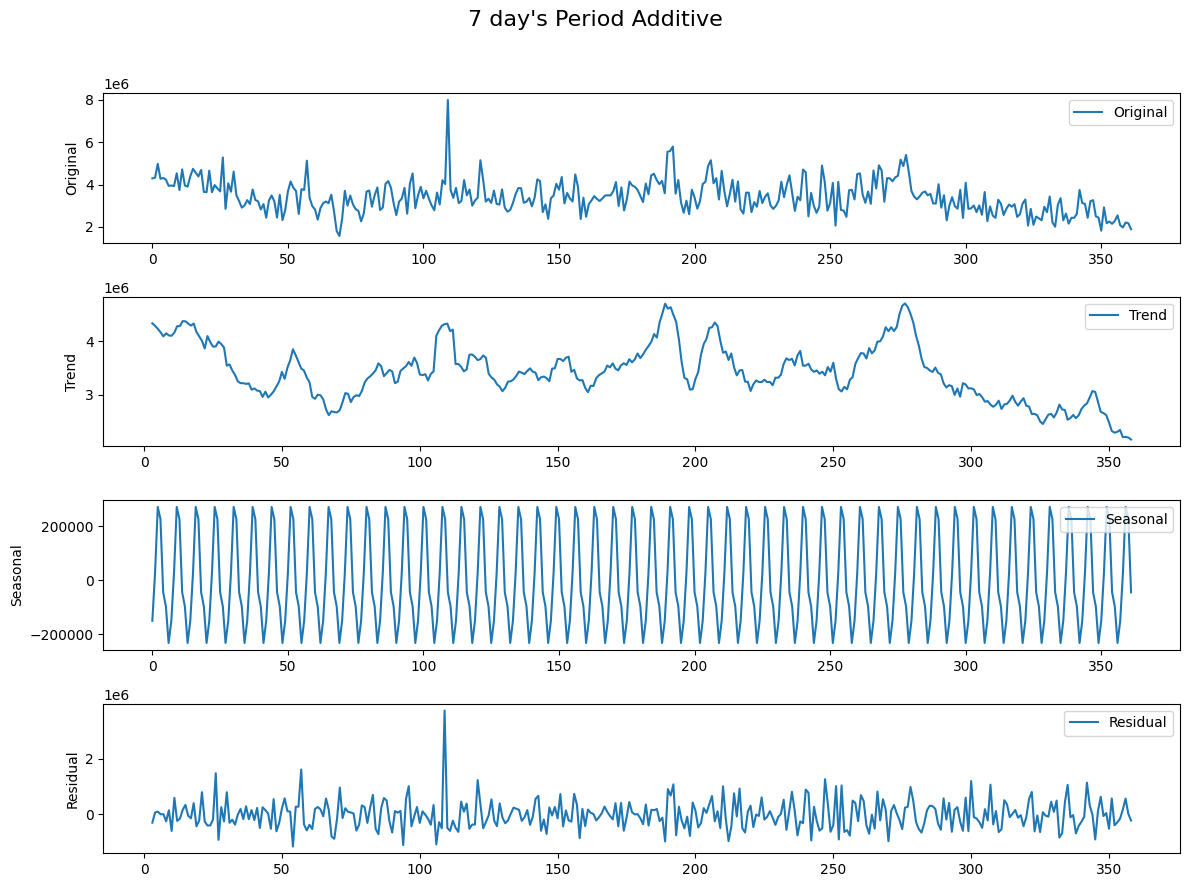

In [ ]:
## data dekomposisi
decomposition = seasonal_decompose(df['Total Penjualan'], period=7, model='additive')

components = {
    'Original': df['Total Penjualan'],
    'Trend': decomposition.trend,
    'Seasonal': decomposition.seasonal,
    'Residual': decomposition.resid
}

plt.figure(figsize=(12, 9))
plt.suptitle("7 day's Period Additive", fontsize=16)

for i, (title, series) in enumerate(components.items(), start=1):
    plt.subplot(4, 1, i)
    plt.plot(df.index, series, label=title)
    plt.legend(loc='best')
    plt.ylabel(title)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

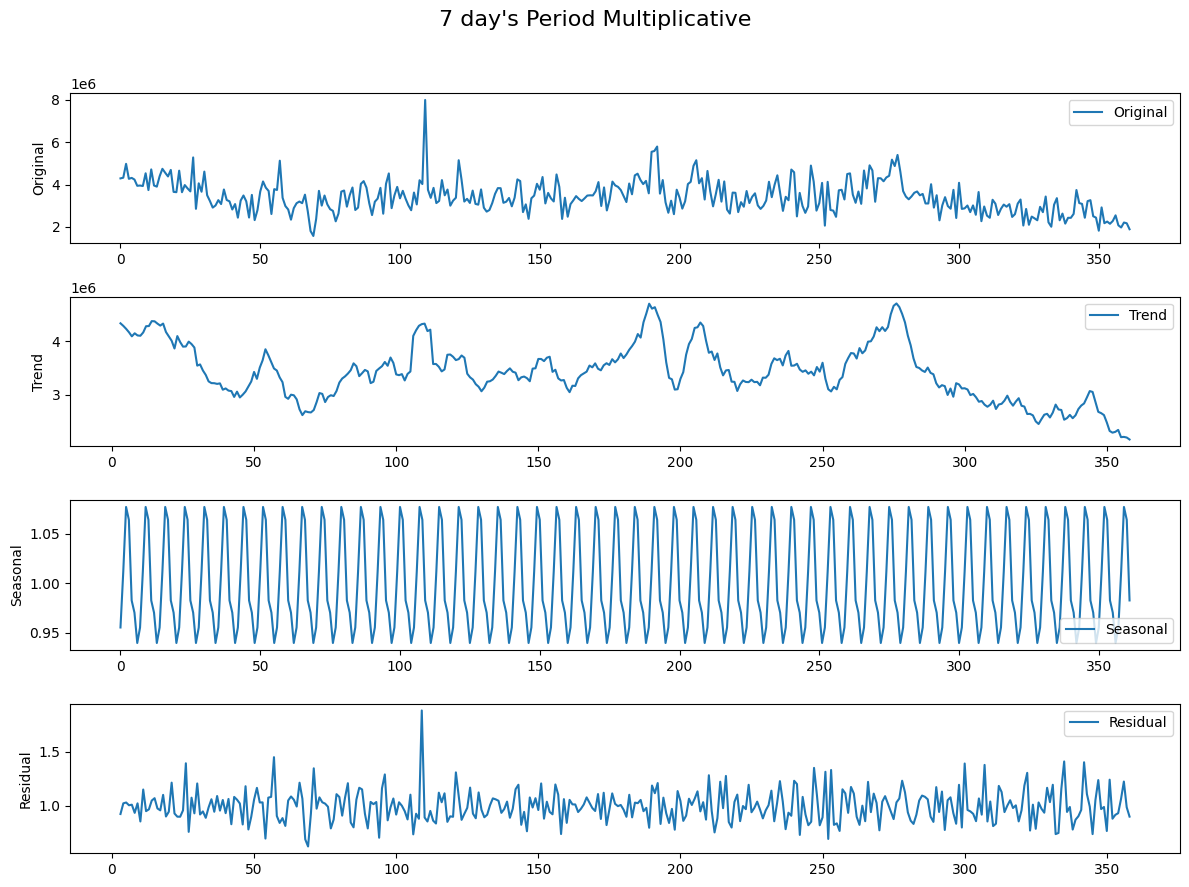

In [ ]:
decomposition = seasonal_decompose(df['Total Penjualan'], period=7, model='multiplicative')

components = {
    'Original': df['Total Penjualan'],
    'Trend': decomposition.trend,
    'Seasonal': decomposition.seasonal,
    'Residual': decomposition.resid
}

plt.figure(figsize=(12, 9))
plt.suptitle("7 day's Period Multiplicative", fontsize=16)

for i, (title, series) in enumerate(components.items(), start=1):
    plt.subplot(4, 1, i)
    plt.plot(df.index, series, label=title)
    plt.legend(loc='best')
    plt.ylabel(title)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

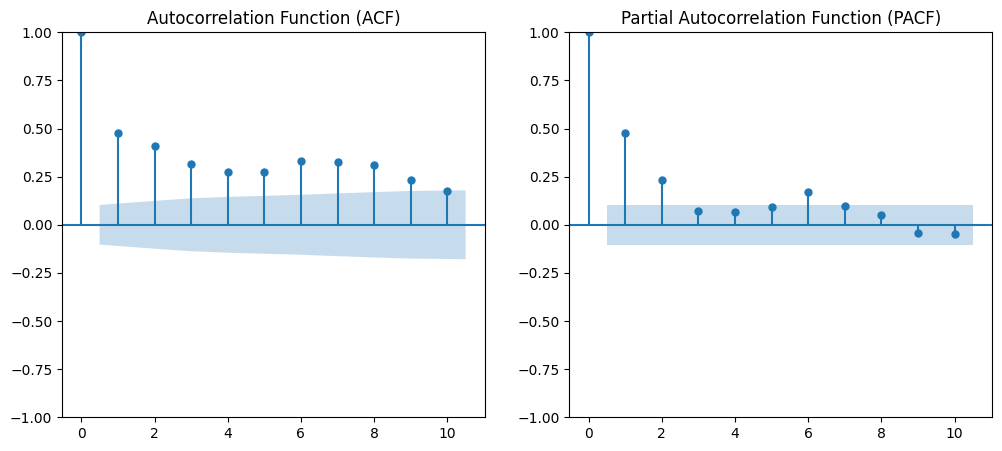

In [ ]:
## acf & pacf
plt.figure(figsize=(12, 5))
plt.subplot(121)
plot_acf(df['Total Penjualan'], lags=10, ax=plt.gca())
plt.title("Autocorrelation Function (ACF)")

plt.subplot(122)
plot_pacf(df['Total Penjualan'], lags=10, ax=plt.gca())
plt.title("Partial Autocorrelation Function (PACF)")
plt.show()

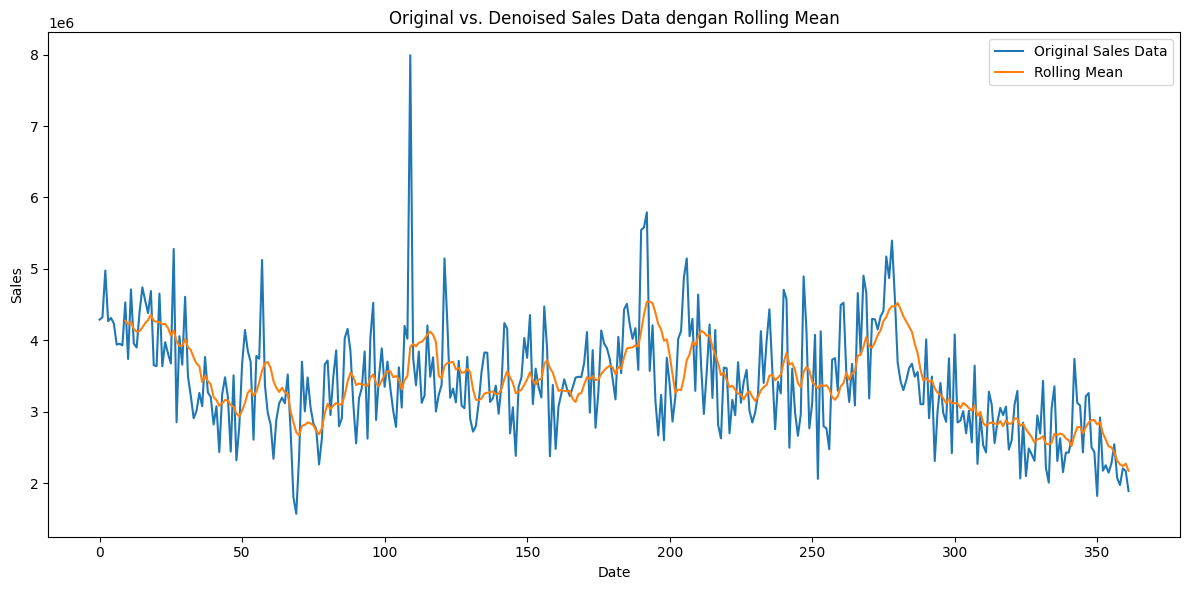

In [ ]:
## rolling mean
rolling_data = df['Total Penjualan'].rolling(window=10).mean()

plt.figure(figsize=(12, 6))
plt.plot(df.index, df['Total Penjualan'], label='Original Sales Data')
plt.plot(df.index, rolling_data, label='Rolling Mean')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.title('Original vs. Denoised Sales Data dengan Rolling Mean')
plt.legend()
plt.tight_layout()
plt.show()

# Features Engineering

In [ ]:
target_col = 'Total Penjualan'

In [ ]:
## time based features
df['year'] = df['Tanggal Penjualan'].dt.year
df['month'] = df['Tanggal Penjualan'].dt.month
df['day'] = df['Tanggal Penjualan'].dt.day
df['dayofweek'] = df['Tanggal Penjualan'].dt.dayofweek
df['dayofyear'] = df['Tanggal Penjualan'].dt.dayofyear
df['weekofyear'] = df['Tanggal Penjualan'].dt.isocalendar().week.astype(int)
df['is_weekend'] = df['dayofweek'].isin([5, 6]).astype(int)

In [ ]:
## rolling statistics
for window in [3, 7, 14, 30]:
    df[f'rolling_mean_{window}'] = df[target_col].shift(1).rolling(window).mean()
    df[f'rolling_std_{window}']  = df[target_col].shift(1).rolling(window).std()
    df[f'rolling_min_{window}']  = df[target_col].shift(1).rolling(window).min()
    df[f'rolling_max_{window}']  = df[target_col].shift(1).rolling(window).max()

In [ ]:
## percentage change
df['Total_Penjualan_capped'] = mstats.winsorize(df[target_col], limits=[0.01, 0.01])
df['pct_change_1'] = df['Total_Penjualan_capped'].shift(1).pct_change(1)
df['pct_change_7'] = df['Total_Penjualan_capped'].shift(1).pct_change(7)

In [ ]:
## lag
for lag in [1, 7, 14]:
    df[f'lag_{lag}'] = df[target_col].shift(lag)

In [ ]:
## fourier transform
def add_fourier_terms(df, period, order, time_col='dayofyear'):
    for k in range(1, order + 1):
        df[f'sin_{period}_{k}'] = np.sin(2 * np.pi * k * df[time_col] / period)
        df[f'cos_{period}_{k}'] = np.cos(2 * np.pi * k * df[time_col] / period)
    return df

df = add_fourier_terms(df, period=7, order=2)
df = add_fourier_terms(df, period=365.25, order=3)

df = df.dropna().reset_index(drop=True)

In [ ]:
df.head()

,Tanggal Penjualan,Total Penjualan,year,month,day,dayofweek,dayofyear,weekofyear,is_weekend,rolling_mean_3,...,sin_7_1,cos_7_1,sin_7_2,cos_7_2,sin_365.25_1,cos_365.25_1,sin_365.25_2,cos_365.25_2,sin_365.25_3,cos_365.25_3
0,2025-07-12,4608750,2025,7,12,5,193,28,1,3.521750e+06,...,-4.338837e-01,-0.900969,7.818315e-01,0.623490,-0.177529,-0.984116,0.349418,0.936967,-0.510207,-0.860052
1,2025-07-13,3493950,2025,7,13,6,194,28,1,4.107667e+06,...,-9.749279e-01,-0.222521,4.338837e-01,-0.900969,-0.194431,-0.980916,0.381441,0.924393,-0.553893,-0.832588
2,2025-07-14,3218750,2025,7,14,0,195,29,0,3.920150e+06,...,-7.818315e-01,0.623490,-9.749279e-01,-0.222521,-0.211276,-0.977426,0.413013,0.910725,-0.596104,-0.802907
3,2025-07-15,2908650,2025,7,15,1,196,29,0,3.773817e+06,...,-6.858022e-15,1.000000,-1.371604e-14,1.000000,-0.228058,-0.973648,0.444096,0.895979,-0.636728,-0.771089
4,2025-07-16,3010000,2025,7,16,2,197,29,0,3.207117e+06,...,7.818315e-01,0.623490,9.749279e-01,-0.222521,-0.244772,-0.969581,0.474653,0.880173,-0.675656,-0.737217


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 332 entries, 0 to 331
Data columns (total 41 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Tanggal Penjualan       332 non-null    datetime64[ns]
 1   Total Penjualan         332 non-null    int64         
 2   year                    332 non-null    int32         
 3   month                   332 non-null    int32         
 4   day                     332 non-null    int32         
 5   dayofweek               332 non-null    int32         
 6   dayofyear               332 non-null    int32         
 7   weekofyear              332 non-null    int64         
 8   is_weekend              332 non-null    int64         
 9   rolling_mean_3          332 non-null    float64       
 10  rolling_std_3           332 non-null    float64       
 11  rolling_min_3           332 non-null    float64       
 12  rolling_max_3           332 non-null    float64   

In [ ]:
results_summary = []

def add_result(model_name, mae, rmse, mape):
    results_summary.append({
        'Model': model_name,
        'MAE': mae,
        'RMSE': rmse,
        'MAPE (%)': mape
    })
    return pd.DataFrame(results_summary)

# Corr

/tmp/ipykernel_4807/2751418649.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=corr_target_sorted.values, y=corr_target_sorted.index, palette=colors)


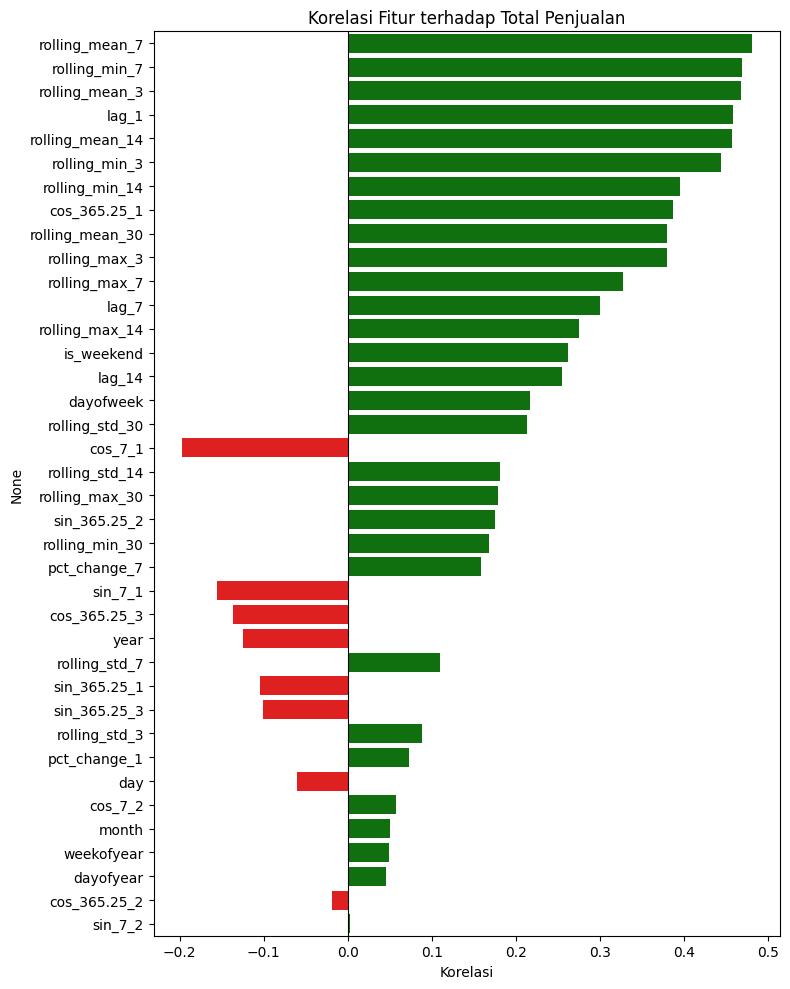

In [ ]:
# Ambil semua kolom numerik (exclude kolom tanggal)
numeric_df = df.drop(columns=['Tanggal Penjualan', 'Total_Penjualan_capped'])

# === 1. Bar Chart Korelasi ke Target ===
target_col = 'Total Penjualan'
corr_target = numeric_df.corr()[target_col].drop(target_col)
corr_target_sorted = corr_target.sort_values(key=abs, ascending=False)

plt.figure(figsize=(8, 10))
colors = ['red' if v < 0 else 'green' for v in corr_target_sorted.values]
sns.barplot(x=corr_target_sorted.values, y=corr_target_sorted.index, palette=colors)
plt.title(f'Korelasi Fitur terhadap {target_col}')
plt.xlabel('Korelasi')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

In [ ]:
target_col = 'Total Penjualan'
numeric_df = df.drop(columns=['Tanggal Penjualan', 'Total_Penjualan_capped'])

# === 1. Filter berdasarkan korelasi ke target (threshold |corr| > 0.15) ===
corr_target = numeric_df.corr()[target_col].drop(target_col)
selected_features = corr_target[abs(corr_target) > 0.15].index.tolist()

selected_features = [f for f in selected_features]

print("Fitur terpilih:", selected_features)

# === 3. Buat dataframe baru untuk Deep Learning (LSTM/iTransformer) ===
df_dl = df[['Tanggal Penjualan', target_col] + selected_features].copy()
df_dl.head()

Fitur terpilih: ['dayofweek', 'is_weekend', 'rolling_mean_3', 'rolling_min_3', 'rolling_max_3', 'rolling_mean_7', 'rolling_min_7', 'rolling_max_7', 'rolling_mean_14', 'rolling_std_14', 'rolling_min_14', 'rolling_max_14', 'rolling_mean_30', 'rolling_std_30', 'rolling_min_30', 'rolling_max_30', 'pct_change_7', 'lag_1', 'lag_7', 'lag_14', 'sin_7_1', 'cos_7_1', 'cos_365.25_1', 'sin_365.25_2']


,Tanggal Penjualan,Total Penjualan,dayofweek,is_weekend,rolling_mean_3,rolling_min_3,rolling_max_3,rolling_mean_7,rolling_min_7,rolling_max_7,...,rolling_min_30,rolling_max_30,pct_change_7,lag_1,lag_7,lag_14,sin_7_1,cos_7_1,cos_365.25_1,sin_365.25_2
0,2025-07-12,4608750,5,1,3.521750e+06,2851000.0,4056500.0,3.900950e+06,2851000.0,5278250.0,...,2851000.0,5278250.0,0.005982,3657750.0,3973000.0,4554950.0,-4.338837e-01,-0.900969,-0.984116,0.349418
1,2025-07-13,3493950,6,1,4.107667e+06,3657750.0,4608750.0,3.991771e+06,2851000.0,5278250.0,...,2851000.0,5278250.0,0.160018,4608750.0,3815700.0,4380650.0,-9.749279e-01,-0.222521,-0.980916,0.381441
2,2025-07-14,3218750,0,0,3.920150e+06,3493950.0,4608750.0,3.945807e+06,2851000.0,5278250.0,...,2851000.0,5278250.0,-0.084323,3493950.0,3674450.0,4689000.0,-7.818315e-01,0.623490,-0.977426,0.413013
3,2025-07-15,2908650,1,0,3.773817e+06,3218750.0,4608750.0,3.880707e+06,2851000.0,5278250.0,...,2851000.0,5278250.0,-0.124019,3218750.0,5278250.0,3651750.0,-6.858022e-15,1.000000,-0.973648,0.444096
4,2025-07-16,3010000,2,0,3.207117e+06,2908650.0,3493950.0,3.542193e+06,2851000.0,4608750.0,...,2851000.0,5278250.0,-0.448937,2908650.0,2851000.0,3637000.0,7.818315e-01,0.623490,-0.969581,0.474653


In [ ]:
df_dl.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 332 entries, 0 to 331
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Tanggal Penjualan  332 non-null    datetime64[ns]
 1   Total Penjualan    332 non-null    int64         
 2   dayofweek          332 non-null    int32         
 3   is_weekend         332 non-null    int64         
 4   rolling_mean_3     332 non-null    float64       
 5   rolling_min_3      332 non-null    float64       
 6   rolling_max_3      332 non-null    float64       
 7   rolling_mean_7     332 non-null    float64       
 8   rolling_min_7      332 non-null    float64       
 9   rolling_max_7      332 non-null    float64       
 10  rolling_mean_14    332 non-null    float64       
 11  rolling_std_14     332 non-null    float64       
 12  rolling_min_14     332 non-null    float64       
 13  rolling_max_14     332 non-null    float64       
 14  rolling_me

# Data Series

In [ ]:
series = df.set_index('Tanggal Penjualan')['Total Penjualan']
series.index = pd.DatetimeIndex(series.index).to_period('D')

scale = 1000
series_scaled = series / scale

# Split train-val-test
train_size = int(len(series_scaled) * 0.9)
train, test = series_scaled[:train_size], series_scaled[train_size:]

val_size = int(train_size * 0.1)
train_only = train[:-val_size].values
val = train[-val_size:].values

test_original = (test * scale).values

# ARIMA

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.42 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=4364.081, Time=0.02 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=4320.147, Time=0.04 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=4279.508, Time=0.23 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=4362.087, Time=0.01 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.22 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=4270.470, Time=0.22 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.33 sec
 ARIMA(0,1,3)(0,0,0)[0] intercept   : AIC=inf, Time=0.57 sec
 ARIMA(1,1,3)(0,0,0)[0] intercept   : AIC=inf, Time=0.69 sec
 ARIMA(0,1,2)(0,0,0)[0]             : AIC=4268.496, Time=0.14 sec
 ARIMA(0,1,1)(0,0,0)[0]             : AIC=4277.509, Time=0.07 sec
 ARIMA(1,1,2)(0,0,0)[0]             : AIC=4263.768, Time=0.31 sec
 ARIMA(1,1,1)(0,0,0)[0]             : AIC=4263.854, Time=0.17 sec
 ARIMA(2,1,2)(0,0,0)[0]             : AIC=4264.822, Time=0

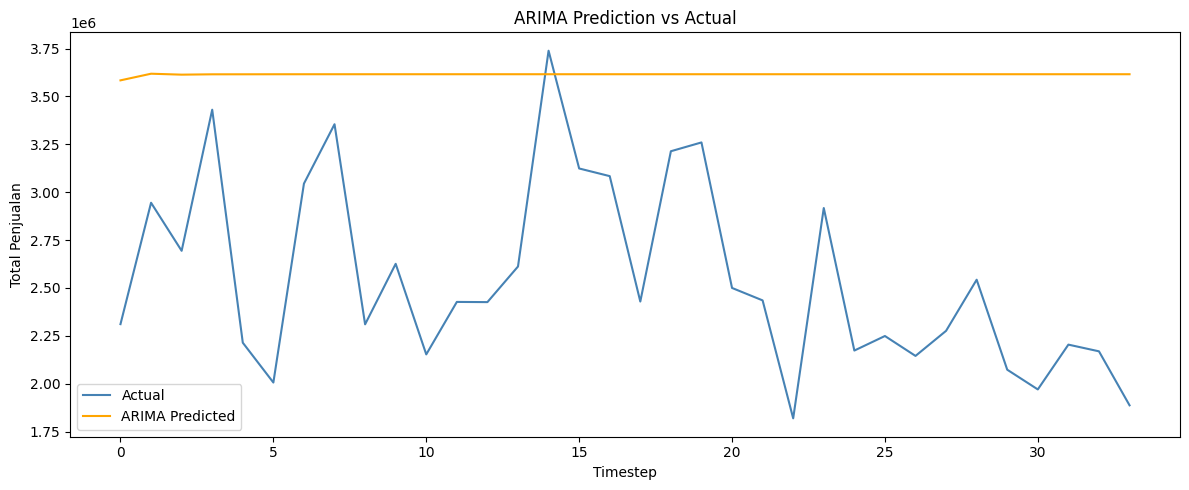

In [ ]:
# === ARIMA (non-seasonal) ===
model_arima = auto_arima(
    train_only,
    seasonal=False,
    trace=True,
    error_action='ignore',
    suppress_warnings=True,
    stepwise=True
)

pred_arima_scaled = model_arima.predict(n_periods=len(test))
pred_arima = pred_arima_scaled * scale

# test_original sudah didefinisikan di cell sebelumnya, tidak perlu diulang

mae_arima = mean_absolute_error(test_original, pred_arima)
rmse_arima = np.sqrt(mean_squared_error(test_original, pred_arima))
mape_arima = np.mean(np.abs((test_original - pred_arima) / test_original)) * 100

print(f"ARIMA MAE: {mae_arima:.2f}")
print(f"ARIMA RMSE: {rmse_arima:.2f}")
print(f"ARIMA MAPE: {mape_arima:.2f}%")

results_df = add_result('ARIMA', mae_arima, rmse_arima, mape_arima)

# === Plot ===
plt.figure(figsize=(12, 5))
plt.plot(test_original, label='Actual', color='steelblue')
plt.plot(pred_arima, label='ARIMA Predicted', color='orange')
plt.title('ARIMA Prediction vs Actual')
plt.xlabel('Timestep')
plt.ylabel('Total Penjualan')
plt.legend()
plt.tight_layout()
plt.show()

# SARIMA

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[7] intercept   : AIC=inf, Time=1.57 sec
 ARIMA(0,1,0)(0,0,0)[7] intercept   : AIC=4364.081, Time=0.02 sec
 ARIMA(1,1,0)(1,0,0)[7] intercept   : AIC=4319.685, Time=0.10 sec
 ARIMA(0,1,1)(0,0,1)[7] intercept   : AIC=4280.632, Time=0.43 sec
 ARIMA(0,1,0)(0,0,0)[7]             : AIC=4362.087, Time=0.01 sec
 ARIMA(0,1,1)(0,0,0)[7] intercept   : AIC=4279.508, Time=0.21 sec
 ARIMA(0,1,1)(1,0,0)[7] intercept   : AIC=4280.402, Time=0.39 sec
 ARIMA(0,1,1)(1,0,1)[7] intercept   : AIC=inf, Time=0.93 sec
 ARIMA(1,1,1)(0,0,0)[7] intercept   : AIC=inf, Time=0.22 sec
 ARIMA(0,1,2)(0,0,0)[7] intercept   : AIC=4270.470, Time=0.22 sec
 ARIMA(0,1,2)(1,0,0)[7] intercept   : AIC=4271.891, Time=0.53 sec
 ARIMA(0,1,2)(0,0,1)[7] intercept   : AIC=4271.998, Time=0.66 sec
 ARIMA(0,1,2)(1,0,1)[7] intercept   : AIC=inf, Time=1.09 sec
 ARIMA(1,1,2)(0,0,0)[7] intercept   : AIC=inf, Time=0.36 sec
 ARIMA(0,1,3)(0,0,0)[7] intercept   : AIC=inf, Time=0.53 s

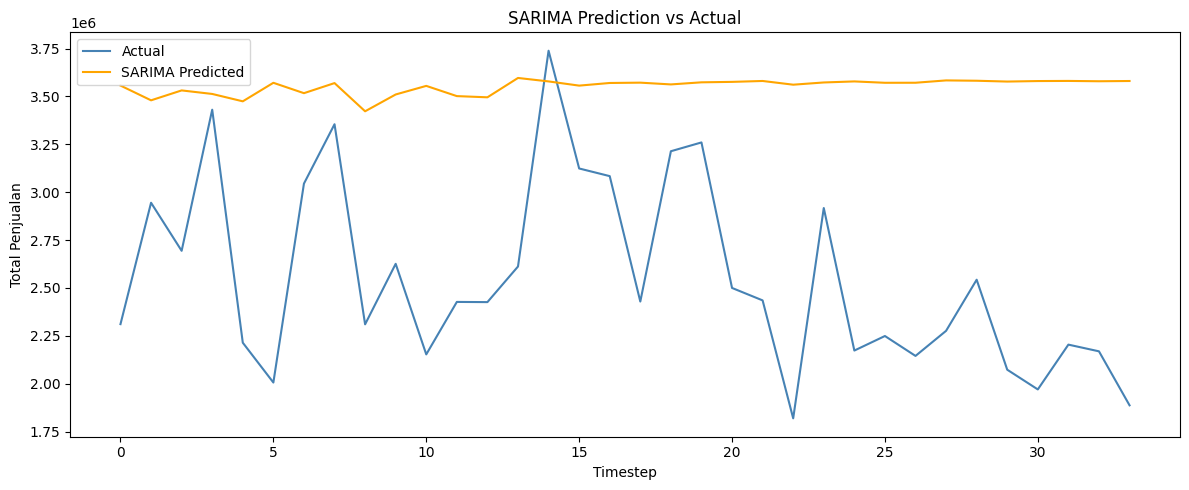

In [ ]:
model_sarima = auto_arima(
    train_only,
    seasonal=True,
    m=7,
    trace=True,
    error_action='ignore',
    suppress_warnings=True,
    stepwise=True
)

pred_sarima_scaled = model_sarima.predict(n_periods=len(test))
pred_sarima = pred_sarima_scaled * scale

mae_sarima = mean_absolute_error(test_original, pred_sarima)
rmse_sarima = np.sqrt(mean_squared_error(test_original, pred_sarima))
mape_sarima = np.mean(np.abs((test_original - pred_sarima) / test_original)) * 100

print(f"SARIMA MAE: {mae_sarima:.2f}")
print(f"SARIMA RMSE: {rmse_sarima:.2f}")
print(f"SARIMA MAPE: {mape_sarima:.2f}%")

results_df = add_result('SARIMA', mae_sarima, rmse_sarima, mape_sarima)

# === Plot ===
plt.figure(figsize=(12, 5))
plt.plot(test_original, label='Actual', color='steelblue')
plt.plot(pred_sarima, label='SARIMA Predicted', color='orange')
plt.title('SARIMA Prediction vs Actual')
plt.xlabel('Timestep')
plt.ylabel('Total Penjualan')
plt.legend()
plt.tight_layout()
plt.show()

# SARIMAX

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,0,1)[7] intercept   : AIC=4336.937, Time=5.90 sec
 ARIMA(0,0,0)(0,0,0)[7] intercept   : AIC=4293.427, Time=0.38 sec
 ARIMA(1,0,0)(1,0,0)[7] intercept   : AIC=4384.767, Time=1.70 sec
 ARIMA(0,0,1)(0,0,1)[7] intercept   : AIC=4499.712, Time=4.52 sec
 ARIMA(0,0,0)(0,0,0)[7]             : AIC=4740.961, Time=0.38 sec
 ARIMA(0,0,0)(1,0,0)[7] intercept   : AIC=4557.534, Time=1.65 sec
 ARIMA(0,0,0)(0,0,1)[7] intercept   : AIC=4616.944, Time=0.68 sec
 ARIMA(0,0,0)(1,0,1)[7] intercept   : AIC=4564.365, Time=1.83 sec
 ARIMA(1,0,0)(0,0,0)[7] intercept   : AIC=4382.460, Time=0.98 sec
 ARIMA(0,0,1)(0,0,0)[7] intercept   : AIC=4277.754, Time=1.40 sec
 ARIMA(0,0,1)(1,0,0)[7] intercept   : AIC=4510.904, Time=0.82 sec
 ARIMA(0,0,1)(1,0,1)[7] intercept   : AIC=4504.269, Time=2.65 sec
 ARIMA(1,0,1)(0,0,0)[7] intercept   : AIC=4332.320, Time=3.28 sec
 ARIMA(0,0,2)(0,0,0)[7] intercept   : AIC=4490.810, Time=1.33 sec
 ARIMA(1,0,2)(0,0,0)[7] intercept

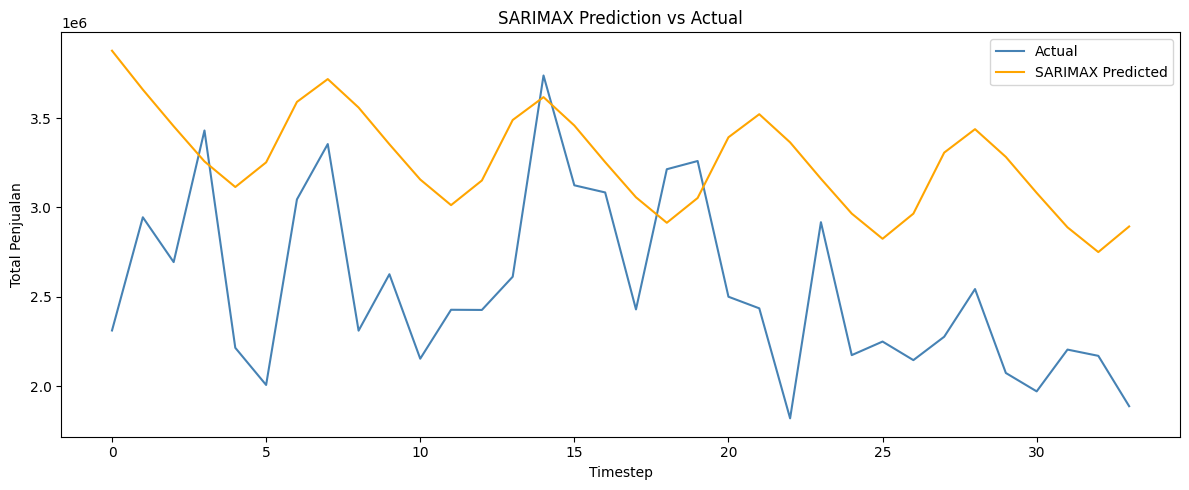

In [ ]:
# Tambahan khusus SARIMAX (exog)
fourier_cols = [c for c in df.columns if c.startswith('sin_') or c.startswith('cos_')]
exog = df[fourier_cols].copy()
exog.index = series.index
exog_train, exog_test = exog[:train_size], exog[train_size:]
exog_train_only = exog_train[:-val_size]
exog_val = exog_train[-val_size:]

# === SARIMAX dengan exog Fourier ===
model_sarimax = auto_arima(
    train_only,
    X=exog_train_only,
    seasonal=True,
    m=7,
    trace=True,
    error_action='ignore',
    suppress_warnings=True,
    stepwise=True
)

pred_sarimax_scaled = model_sarimax.predict(n_periods=len(test), X=exog_test)
pred_sarimax = np.array(pred_sarimax_scaled) * scale

mae_sarimax = mean_absolute_error(test_original, pred_sarimax)
rmse_sarimax = np.sqrt(mean_squared_error(test_original, pred_sarimax))
mape_sarimax = np.mean(np.abs((test_original - pred_sarimax) / test_original)) * 100

print(f"SARIMAX MAE: {mae_sarimax:.2f}")
print(f"SARIMAX RMSE: {rmse_sarimax:.2f}")
print(f"SARIMAX MAPE: {mape_sarimax:.2f}%")

results_df = add_result('SARIMAX', mae_sarimax, rmse_sarimax, mape_sarimax)

plt.figure(figsize=(12, 5))
plt.plot(test_original, label='Actual', color='steelblue')
plt.plot(pred_sarimax, label='SARIMAX Predicted', color='orange')
plt.title('SARIMAX Prediction vs Actual')
plt.xlabel('Timestep')
plt.ylabel('Total Penjualan')
plt.legend()
plt.tight_layout()
plt.show()

# LSTM

In [ ]:
target_col = 'Total Penjualan'
data = df_dl.drop(columns=['Tanggal Penjualan']).copy()

# === Split train-val-test (time-based) ===
train_size = int(len(data) * 0.8)
val_size = int(len(data) * 0.1)

train_df = data[:train_size]
val_df = data[train_size:train_size + val_size]
test_df = data[train_size + val_size:]

print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")

# === Scaling (fit hanya di train) ===
feature_scaler = MinMaxScaler()
target_scaler = MinMaxScaler()

train_scaled = feature_scaler.fit_transform(train_df)
val_scaled = feature_scaler.transform(val_df)
test_scaled = feature_scaler.transform(test_df)

target_idx = data.columns.get_loc(target_col)
target_scaler.fit(train_df[[target_col]])


Train: 265, Val: 33, Test: 34


MinMaxScaler()

In [ ]:
# === Buat sequence (sliding window) ===
def create_sequences(data, target_idx, window_size):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:i+window_size])
        y.append(data[i+window_size, target_idx])
    return np.array(X), np.array(y)

window_size = 7

# Gabung semua agar window di awal val/test dapat konteks
full_scaled = np.vstack([train_scaled, val_scaled, test_scaled])
X_all, y_all = create_sequences(full_scaled, target_idx, window_size)

train_len = train_size - window_size
val_len = train_len + val_size

X_train = X_all[:train_len]
y_train = y_all[:train_len]
X_val = X_all[train_len:val_len]
y_val = y_all[train_len:val_len]
X_test = X_all[val_len:]
y_test = y_all[val_len:]

print("X_train:", X_train.shape, "X_val:", X_val.shape, "X_test:", X_test.shape)

X_train: (258, 7, 25) X_val: (33, 7, 25) X_test: (34, 7, 25)


In [ ]:
# === Bangun model LSTM (kompleks) ===
n_features = X_train.shape[2]

model = Sequential([
    LSTM(256, return_sequences=True, input_shape=(window_size, n_features)),
    Dropout(0.2),
    BatchNormalization(),

    LSTM(128, return_sequences=True),
    Dropout(0.2),
    BatchNormalization(),

    LSTM(64, return_sequences=True),
    Dropout(0.2),
    BatchNormalization(),

    LSTM(64, return_sequences=True),
    Dropout(0.2),

    LSTM(32, return_sequences=False),
    Dropout(0.2),

    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 7, 256)         │       288,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 7, 256)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 7, 256)         │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 7, 128)         │       197,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 7, 128)         │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 7, 64)          │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 7, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 7, 64)          │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 7, 64)          │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 7, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 584,129 (2.23 MB)

 Trainable params: 583,233 (2.22 MB)

 Non-trainable params: 896 (3.50 KB)

In [ ]:
# === Training ===
early_stop = EarlyStopping(monitor='val_loss', patience=30, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=1e-5)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=200,
    batch_size=16,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 15s 134ms/step - loss: 0.0460 - mae: 0.1637 - val_loss: 0.0144 - val_mae: 0.1005 - learning_rate: 0.0010
Epoch 2/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step - loss: 0.0174 - mae: 0.0998 - val_loss: 0.0089 - val_mae: 0.0739 - learning_rate: 0.0010
Epoch 3/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - loss: 0.0141 - mae: 0.0889 - val_loss: 0.0079 - val_mae: 0.0686 - learning_rate: 0.0010
Epoch 4/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - loss: 0.0122 - mae: 0.0840 - val_loss: 0.0074 - val_mae: 0.0663 - learning_rate: 0.0010
Epoch 5/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - loss: 0.0145 - mae: 0.0925 - val_loss: 0.0082 - val_mae: 0.0701 - learning_rate: 0.0010
Epoch 6/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - loss: 0.0120 - mae: 0.0868 - val_loss: 0.0054 - val_mae: 0.0606 - learning_rate: 0.0010
Epoch 7/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - loss: 0.0129 - mae: 0.0830 - val_loss: 0.0048 - val_mae: 0.0562 - learning_rate: 0.0010
Epoc

2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 838ms/step
LSTM MAE: 482973.34
LSTM RMSE: 534993.04
LSTM MAPE: 20.32%


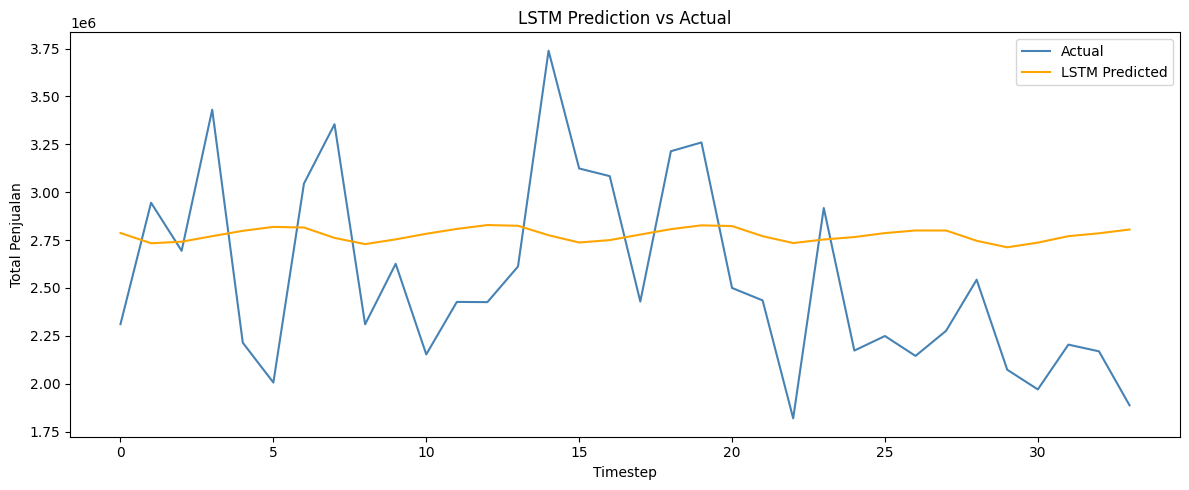

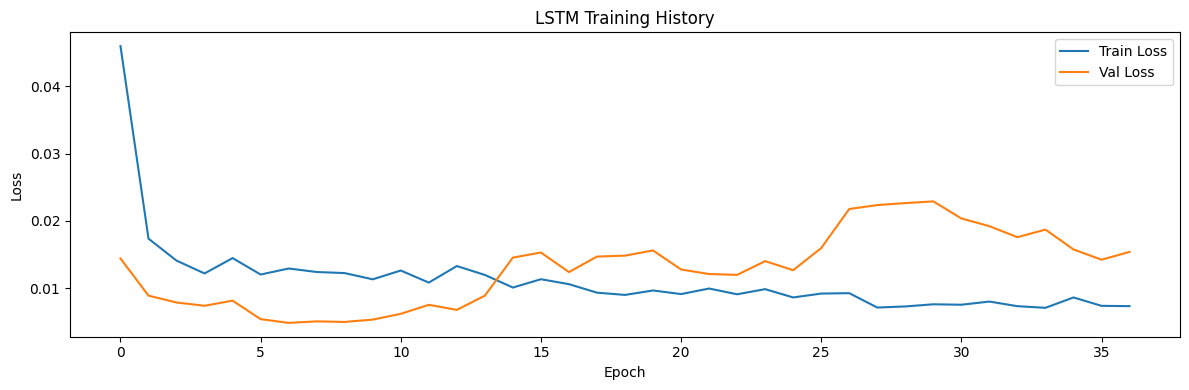

In [ ]:
# === Evaluasi di test set ===
y_pred_scaled = model.predict(X_test)

y_pred = target_scaler.inverse_transform(y_pred_scaled)
y_true = target_scaler.inverse_transform(y_test.reshape(-1, 1))

mae_lstm = mean_absolute_error(y_true, y_pred)
rmse_lstm = np.sqrt(mean_squared_error(y_true, y_pred))
mape_lstm = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

print(f"LSTM MAE: {mae_lstm:.2f}")
print(f"LSTM RMSE: {rmse_lstm:.2f}")
print(f"LSTM MAPE: {mape_lstm:.2f}%")

results_df = add_result('LSTM', mae_lstm, rmse_lstm, mape_lstm)

# === Plot Prediction vs Actual ===
plt.figure(figsize=(12, 5))
plt.plot(y_true, label='Actual', color='steelblue')
plt.plot(y_pred, label='LSTM Predicted', color='orange')
plt.title('LSTM Prediction vs Actual')
plt.xlabel('Timestep')
plt.ylabel('Total Penjualan')
plt.legend()
plt.tight_layout()
plt.show()

# === Plot Training History ===
plt.figure(figsize=(12, 4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('LSTM Training History')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

# iTransformer

INFO:lightning_fabric.utilities.seed:Seed set to 1
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores


Memulai proses training...


INFO:pytorch_lightning.callbacks.model_summary:
  | Name          | Type                   | Params | Mode 
-----------------------------------------------------------------
0 | loss          | MAE                    | 0      | train
1 | padder_train  | ConstantPad1d          | 0      | train
2 | scaler        | TemporalNorm           | 0      | train
3 | enc_embedding | DataEmbedding_inverted | 15.9 K | train
4 | encoder       | TransEncoder           | 6.3 M  | train
5 | projector     | Linear                 | 15.4 K | train
-----------------------------------------------------------------
6.3 M     Trainable params
0         Non-trainable params
6.3 M     Total params
25.348    Total estimated model params size (MB)
36        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=250` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Predicting: |          | 0/? [00:00<?, ?it/s]


 Result
MAE  : 494407.72
RMSE : 574707.37
MAPE : 21.00


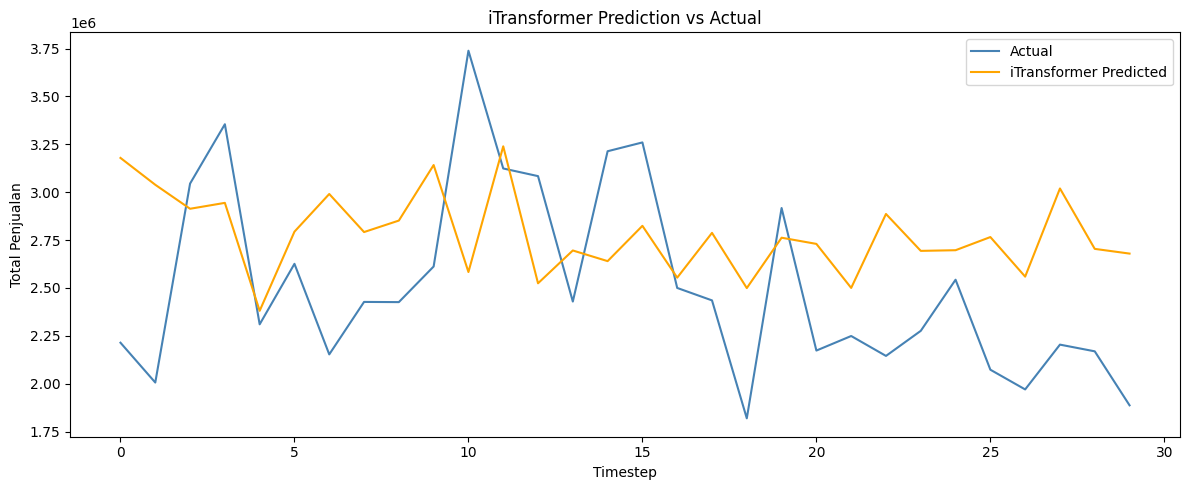

In [ ]:
target_col = 'Total Penjualan'

nf_df = df_dl.rename(columns={'Tanggal Penjualan': 'ds', target_col: 'y'}).copy()
nf_df['unique_id'] = 'sales'
nf_df = nf_df[['unique_id', 'ds', 'y']]

# === Split train-test ===
horizon = 30
val_size = 30

train_df = nf_df.iloc[:-(horizon)].reset_index(drop=True)
test_df = nf_df.iloc[-horizon:].reset_index(drop=True)

# === Model iTransformer ===
model = iTransformer(
    h=horizon,
    input_size=30,
    n_series=1,
    max_steps=250
)

nf = NeuralForecast(models=[model], freq='D')

print("Memulai proses training...")
nf.fit(df=train_df, val_size=val_size)  # val_size dihandle internal

forecast_df = nf.predict().reset_index()
eval_df = forecast_df.merge(test_df[['unique_id', 'ds', 'y']], on=['unique_id', 'ds'])

mae_tf = mean_absolute_error(eval_df['y'], eval_df['iTransformer'])
rmse_tf = np.sqrt(mean_squared_error(eval_df['y'], eval_df['iTransformer']))
mape_tf = np.nanmean(np.abs((eval_df['y'] - eval_df['iTransformer']) / eval_df['y'].replace(0, np.nan))) * 100

print("\n Result")
print(f"MAE  : {mae_tf:.2f}")
print(f"RMSE : {rmse_tf:.2f}")
print(f"MAPE : {mape_tf:.2f}")
results_df = add_result('iTransformer', mae_tf, rmse_tf, mape_tf)

# === Plot ===
plt.figure(figsize=(12, 5))
plt.plot(eval_df['y'].values, label='Actual', color='steelblue')
plt.plot(eval_df['iTransformer'].values, label='iTransformer Predicted', color='orange')
plt.title('iTransformer Prediction vs Actual')
plt.xlabel('Timestep')
plt.ylabel('Total Penjualan')
plt.legend()
plt.tight_layout()
plt.show()

# XGBoost

XGBoost MAE: 74744.62
XGBoost RMSE: 104960.85
XGBoost MAPE: 3.34%


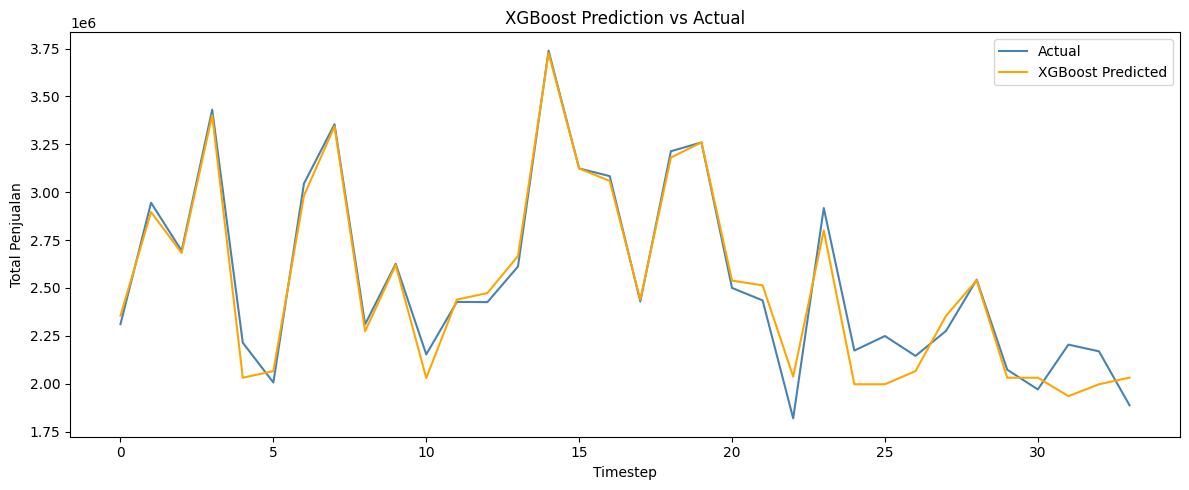

In [ ]:
target_col = 'Total Penjualan'

data_xgb = df.drop(columns=['Tanggal Penjualan']).copy()

X = data_xgb.drop(columns=[target_col])
y = data_xgb[target_col]

## split
train_size = int(len(data_xgb) * 0.9)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

val_size = int(train_size * 0.1)
X_tr, X_val = X_train[:-val_size], X_train[-val_size:]
y_tr, y_val = y_train[:-val_size], y_train[-val_size:]

## model
model_xgb = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=2,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    early_stopping_rounds=30,
    eval_metric='mae'
)

model_xgb.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)

## predict & eval
pred_xgb = model_xgb.predict(X_test)

mae_xgb = mean_absolute_error(y_test, pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, pred_xgb))
mape_xgb = np.mean(np.abs((y_test - pred_xgb) / y_test)) * 100

print(f"XGBoost MAE: {mae_xgb:.2f}")
print(f"XGBoost RMSE: {rmse_xgb:.2f}")
print(f"XGBoost MAPE: {mape_xgb:.2f}%")

results_df = add_result('XGBoost', mae_xgb, rmse_xgb, mape_xgb)

# === Plot ===
plt.figure(figsize=(12, 5))
plt.plot(y_test.values, label='Actual', color='steelblue')
plt.plot(pred_xgb, label='XGBoost Predicted', color='orange')
plt.title('XGBoost Prediction vs Actual')
plt.xlabel('Timestep')
plt.ylabel('Total Penjualan')
plt.legend()
plt.tight_layout()
plt.show()

# Facebook Prophet

Train: 269, Val: 29, Test: 34
Prophet MAE: 875615.62
Prophet RMSE: 1001298.50
Prophet MAPE: 38.35%


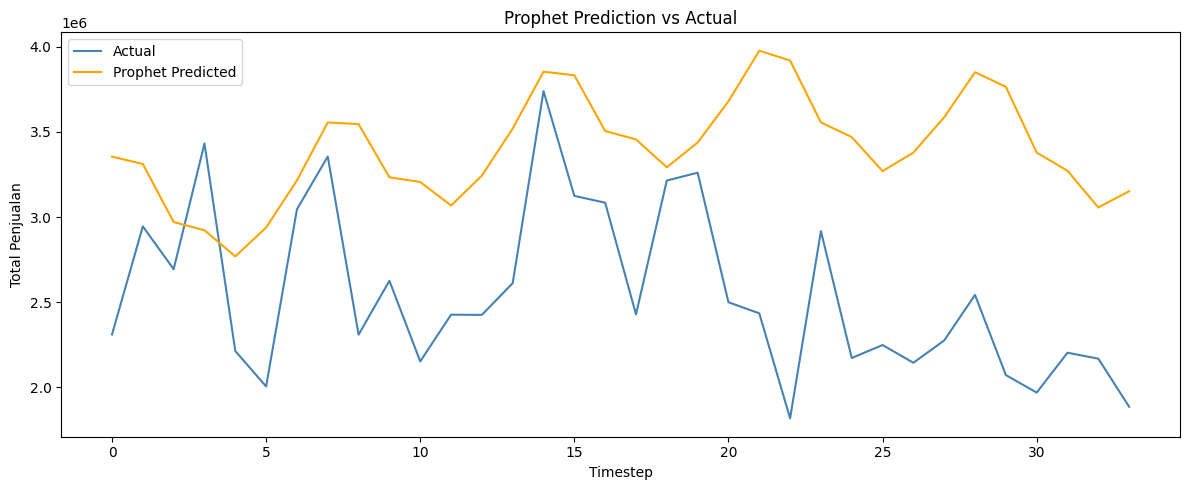

In [ ]:
target_col = 'Total Penjualan'

# === Siapkan data format Prophet (ds, y) ===
prophet_df = df[['Tanggal Penjualan', target_col]].rename(
    columns={'Tanggal Penjualan': 'ds', target_col: 'y'}
)

# === Split train-val-test (time-based) ===
train_size = int(len(prophet_df) * 0.9)
val_size = int(train_size * 0.1)

train_only_df = prophet_df[:train_size - val_size]
val_df = prophet_df[train_size - val_size:train_size]
test_df = prophet_df[train_size:].reset_index(drop=True)

print(f"Train: {len(train_only_df)}, Val: {len(val_df)}, Test: {len(test_df)}")

# === Model Prophet ===
model_prophet = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    seasonality_mode='multiplicative'
)

model_prophet.fit(train_only_df)

# === Prediksi ===
future = model_prophet.make_future_dataframe(periods=len(test_df), freq='D')
forecast = model_prophet.predict(future)

pred_prophet = forecast[['ds', 'yhat']].tail(len(test_df)).reset_index(drop=True)
y_true = test_df['y'].reset_index(drop=True)

# === Evaluasi ===
mae_prophet = mean_absolute_error(y_true, pred_prophet['yhat'])
rmse_prophet = np.sqrt(mean_squared_error(y_true, pred_prophet['yhat']))
mape_prophet = np.mean(np.abs((y_true - pred_prophet['yhat']) / y_true)) * 100

print(f"Prophet MAE: {mae_prophet:.2f}")
print(f"Prophet RMSE: {rmse_prophet:.2f}")
print(f"Prophet MAPE: {mape_prophet:.2f}%")

results_df = add_result('Prophet', mae_prophet, rmse_prophet, mape_prophet)

# === Plot ===
plt.figure(figsize=(12, 5))
plt.plot(y_true.values, label='Actual', color='steelblue')
plt.plot(pred_prophet['yhat'].values, label='Prophet Predicted', color='orange')
plt.title('Prophet Prediction vs Actual')
plt.xlabel('Timestep')
plt.ylabel('Total Penjualan')
plt.legend()
plt.tight_layout()
plt.show()

# Result Comparison

In [ ]:
results_df

,Model,MAE,RMSE,MAPE (%)
0,ARIMA,875174.252947,988536.276232,36.007620
1,SARIMA,851621.965924,967918.166349,34.996422
2,SARIMAX,375771.561835,492381.038370,16.242103
3,LSTM,408219.352941,483318.291452,16.202309
4,LSTM,531710.875000,618494.278143,22.971904
5,XGBoost,90612.789062,118421.005704,3.896177
6,Prophet,592336.483065,688118.619153,22.769555


# Save Model

In [ ]:
joblib.dump(model_xgb, 'model_xgb.pkl')

['model_xgb.pkl']